In [1]:
import scanpy as sc
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder


d:\GP\Scimilarity_test\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Baron_Pancreas_Combined_Human_Mouse.h5ad")
print(adata1)


AnnData object with n_obs × n_vars = 9436 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'


In [3]:
adata = adata1[adata1.obs["species"] == "mouse"]
print(adata)

View of AnnData object with n_obs × n_vars = 1868 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'


In [4]:
# write the adata to a new h5ad file
adata.write_h5ad(r"D:\GP\Notebooks\Scimilarity\Baron_Pancreas_Mouse.h5ad")

In [5]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [6]:
adata.layers["counts"] = adata.X.copy()


C:\Users\loq\AppData\Local\Temp\ipykernel_37052\1570644132.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [7]:
adata = adata[adata.obs["cell_type"] != "Other"].copy()
print(adata.obs["cell_type"].value_counts())
labels = adata.obs["cell_type"]
X = adata.X
print("Number of classes:", labels.nunique())

cell_type
beta                  894
ductal                275
delta                 218
alpha                 191
endothelial           139
quiescent_stellate     47
gamma                  41
macrophage             36
activated_stellate     14
t_cell                  7
schwann                 6
Name: count, dtype: int64
Number of classes: 11


In [8]:
from scimilarity.utils import align_dataset, lognorm_counts
adata = align_dataset(adata, ce.gene_order)
adata = lognorm_counts(adata)


In [9]:
X = adata.X  # sparse or dense is fine

embeddings = ce.get_embeddings(X)
# pass as column in adata
adata.obsm["X_emb"] = embeddings
print(embeddings.shape)


(1868, 128)


In [10]:
# save embeddings to project directory
adata.write_h5ad("D:/GP/Notebooks/Scimilarity/Baron_Pancreas_Mouse_embeddings.h5ad")


In [11]:
print(adata.obs['cell_type'])

0-mouse_1                     beta
1-mouse_1                   ductal
2-mouse_1                    delta
3-mouse_1                  schwann
4-mouse_1                    delta
                       ...        
1059-mouse_2                  beta
1060-mouse_2                  beta
1061-mouse_2                ductal
1062-mouse_2    quiescent_stellate
1063-mouse_2                ductal
Name: cell_type, Length: 1868, dtype: category
Categories (11, object): ['activated_stellate', 'alpha', 'beta', 'delta', ..., 'macrophage', 'quiescent_stellate', 'schwann', 't_cell']


In [12]:


from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# logistic regression with cross-validation

clf = LogisticRegression(max_iter=300, solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
x = adata.obsm["X_emb"]
y = adata.obs["cell_type"] 
y_pred_lr = cross_val_predict(clf, x , y, cv=kf)

# knn with cross-validation
from sklearn.neighbors import KNeighborsClassifier
# knn
# train
knn = KNeighborsClassifier(n_neighbors=15,
    weights="distance",
    metric="cosine")
knn.fit(x, y)
# test
y_pred_knn = cross_val_predict(knn, x , y, cv=kf)



In [13]:
# print y_pred and check classes
print(np.unique(y_pred_lr))
print(np.unique(y_pred_knn))

['activated_stellate' 'alpha' 'beta' 'delta' 'ductal' 'endothelial'
 'macrophage' 'quiescent_stellate' 't_cell']
['activated_stellate' 'alpha' 'beta' 'delta' 'ductal' 'endothelial'
 'gamma' 'macrophage' 'quiescent_stellate' 'schwann' 't_cell']


In [14]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model
print("Accuracy (Logistic Regression):", accuracy_score(y, y_pred_lr))
print("Classification Report (Logistic Regression):\n", classification_report(y, y_pred_lr, zero_division=0))

print("Accuracy (k-NN):", accuracy_score(y, y_pred_knn))
print("Classification Report (k-NN):\n", classification_report(y, y_pred_knn))

Accuracy (Logistic Regression): 0.8088865096359743
Classification Report (Logistic Regression):
                     precision    recall  f1-score   support

activated_stellate       1.00      0.50      0.67        14
             alpha       0.86      0.26      0.40       191
              beta       0.74      1.00      0.85       894
             delta       0.75      0.33      0.46       218
            ductal       1.00      0.99      0.99       275
       endothelial       0.98      0.97      0.97       139
             gamma       0.00      0.00      0.00        41
        macrophage       0.97      1.00      0.99        36
quiescent_stellate       0.82      0.96      0.88        47
           schwann       0.00      0.00      0.00         6
            t_cell       1.00      0.71      0.83         7

          accuracy                           0.81      1868
         macro avg       0.74      0.61      0.64      1868
      weighted avg       0.80      0.81      0.77      1868



In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

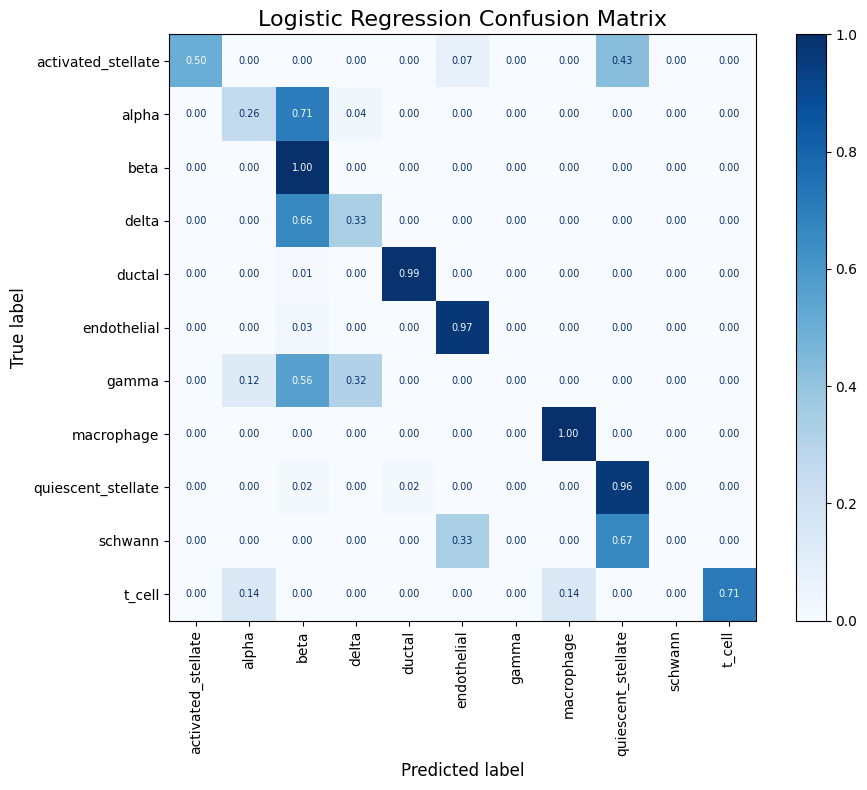

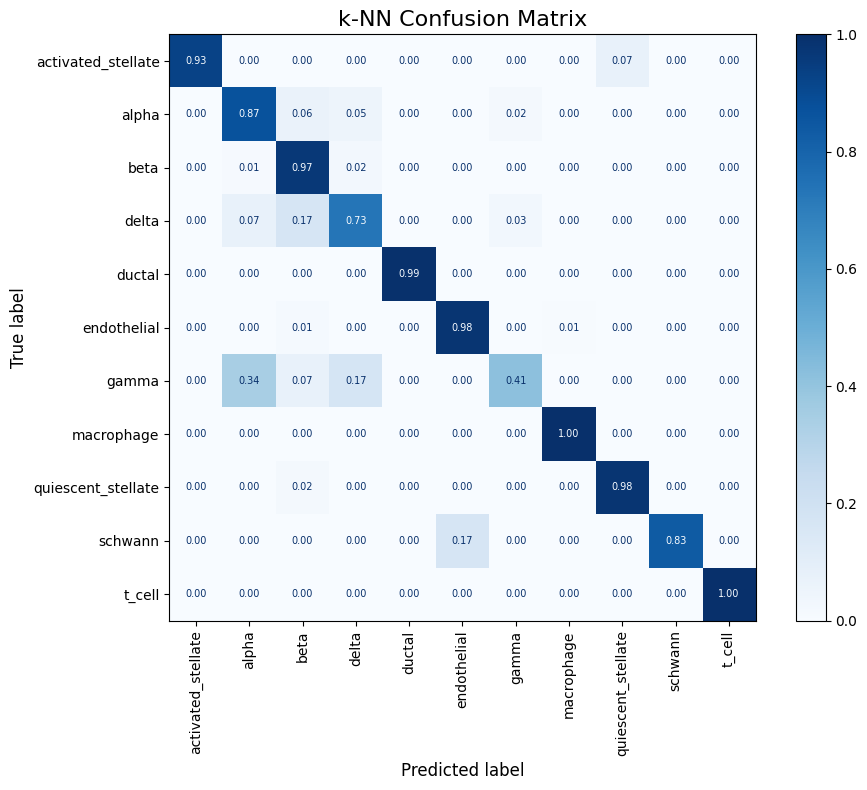

In [16]:
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

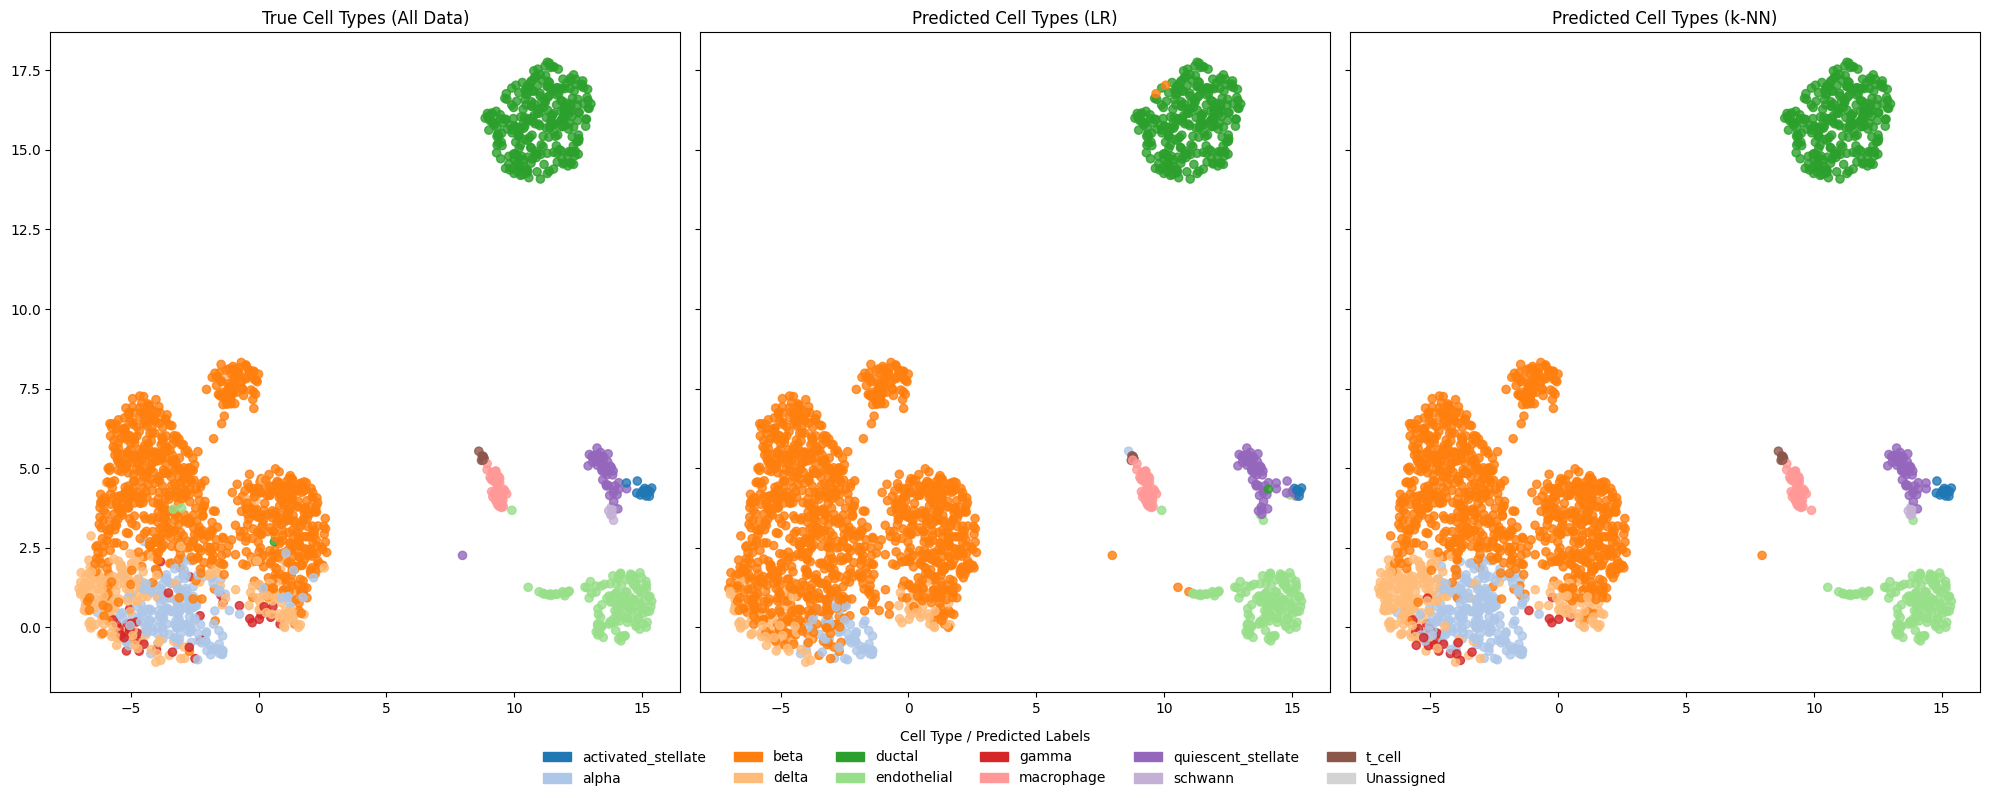

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

# Fill missing predicted labels
adata.obs['y_pred_lr'] = pd.Series(y_pred_lr, index=adata.obs_names).astype(str).fillna('Unassigned')
adata.obs['y_pred_knn'] = pd.Series(y_pred_knn, index=adata.obs_names).astype(str).fillna('Unassigned')

# PCA + neighbors + UMAP on full data
sc.pp.neighbors(adata, use_rep='X_emb', n_neighbors=15)
sc.tl.umap(adata)


# # Subset predicted cells only
# test_adata = adata[adata.obs['y_pred'] != 'Unassigned'].copy()

# Unified label categories
all_labels = pd.Categorical(pd.concat([
    pd.Series(adata.obs['cell_type'].cat.categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_lr']).categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_knn']).categories)
    
], ignore_index=True)).categories

# Color map
palette = sc.pl.palettes.vega_20
label_to_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}
label_to_color['Unassigned'] = 'lightgray'

# Add color columns to adata
adata.obs['color_true'] = adata.obs['cell_type'].map(label_to_color)
adata.obs['color_pred_lr'] = adata.obs['y_pred_lr'].map(label_to_color)
adata.obs['color_pred_knn'] = adata.obs['y_pred_knn'].map(label_to_color)
# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharex=True, sharey=True)

axes[0].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_true'], s=35, alpha=0.8)
axes[0].set_title('True Cell Types (All Data)')

axes[1].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_pred_lr'], s=35, alpha=0.8)
axes[1].set_title('Predicted Cell Types (LR)')

axes[2].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_pred_knn'], s=35, alpha=0.8)
axes[2].set_title('Predicted Cell Types (k-NN)')

# Shared legend
handles = [Patch(color=color, label=lbl) for lbl, color in label_to_color.items()]
fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)



plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
